# ECPM — Heating Model Analysis (Additive Curve Fit)

Fits a 2-variable additive model to the heating component of the ECPM equation:

$$E_h = c_{h1}(T_h - T_{ext})^+ + c_{h2}(T_{int} - T_h)^+ \cdot \theta(T_h - T_{ext})$$

where $\theta(T_h - T_{ext}) = 1$ if $T_{ext} < T_h$, else $0$.

The model uses `scipy.optimize.curve_fit` with non-negative coefficient constraints,
fitted **exclusively on heating-period days** ($T_{ext} < T_h$).

| Variable | Expression | Description |
|---|---|---|
| X1 | $(T_h - T_{ext})^+$ | Exterior temperature below $T_h$ |
| X2 | $(T_{int} - T_h)^+$ | Interior temperature above $T_h$ |

> **Model selection:** AIC (lower = better).
> **ASHRAE Guideline 14:** CV-RMSE ≤ 25 % and |NMBE| ≤ 5 %

## 0 · Setup

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path

DATA_DIR  = Path("../Prepared_Data")
CPM_PARAM = Path("../CPM_Results/AllYears_Preprocessed_Method1")

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

COLORS = {
    'weekday':    '#2271B5',
    'weekend':    '#E9672A',
    'actual_wd':  '#888888',
    'actual_we':  '#BBBBBB',
}

print('All packages loaded.')


All packages loaded.


## 1 · Load data

In [28]:
ENERGY_CSV    = DATA_DIR / 'KEPCO_AllYears_Preprocessed_Method1.csv'
CP_PARAMS_CSV = CPM_PARAM / 'KEPCO_Yearly_CPM_Parameters.csv'

df = pd.read_csv(ENERGY_CSV)
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.dropna(subset=['electricity_kWh', 'temp_external', 'temp_internal', 'is_weekend'])
df = df.sort_values('datetime').reset_index(drop=True)
df['is_weekend'] = df['is_weekend'].astype(int)
df['day_type']   = df['is_weekend'].map({0: 'weekday', 1: 'weekend'})

floor_area_m2 = (df['electricity_kWh'] * 1000 / df['EUI_Wh_m2']).median()

print(f'Total rows : {len(df)}')
print(f'Weekdays   : {(df["is_weekend"]==0).sum()}')
print(f'Weekends   : {(df["is_weekend"]==1).sum()}')
print(f'Date range : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Years      : {sorted(df["year"].unique())}')
print(f'Floor area : {floor_area_m2:.1f} m²')
df.head(3)


Total rows : 763
Weekdays   : 604
Weekends   : 159
Date range : 2020-04-17 → 2025-08-25
Years      : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Floor area : 5381.0 m²


,datetime,year,is_weekend,electricity_kWh,temp_external,temp_internal,EUI_Wh_m2,day_type
0,2020-04-17,2020,0,54.583333,12.902246,21.724062,10.143678,weekday
1,2020-04-19,2020,1,28.916667,12.943029,19.284050,5.373826,weekend
2,2020-04-21,2020,0,57.343750,8.183979,20.794250,10.656669,weekday


In [29]:
cp = pd.read_csv(CP_PARAMS_CSV)

# Normalise column names
for c in cp.columns:
    if c.lower() == 'year' and c != 'year':
        cp = cp.rename(columns={c: 'year'}); break

if 'Tc' not in cp.columns and 'tau_c' in cp.columns:
    cp = cp.rename(columns={'tau_c': 'Tc', 'tau_h': 'Th'})

cp['day_type'] = cp['day_type'].str.lower().str.strip().str.rstrip('s')
cp['year']     = cp['year'].astype(str)

print('cp_params loaded:')
print(cp[['year', 'day_type', 'Tc', 'Th', 'alpha']].to_string(index=False))


cp_params loaded:
year day_type        Tc        Th    alpha
2020  weekday 19.850957 15.717472 8.088002
2021  weekday 19.279155 16.050205 8.088256
2022  weekday 19.103497 15.605047 8.571796
2023  weekday 19.000000 17.471349 8.558636
2024  weekday 19.000000 18.000000 8.176988
2025  weekday 19.003527 14.920923 9.222514
2020  weekend 23.413117 17.999618 4.986828
2021  weekend 24.571534 17.565248 4.883707
2022  weekend 19.000000  8.005670 5.385289
2023  weekend 30.000000 18.000000 5.738792
2024  weekend 19.000000  9.092424 5.482651
2025  weekend 22.517239 14.891419 5.808324


## 1b · EDA — EUI vs Temperature Features

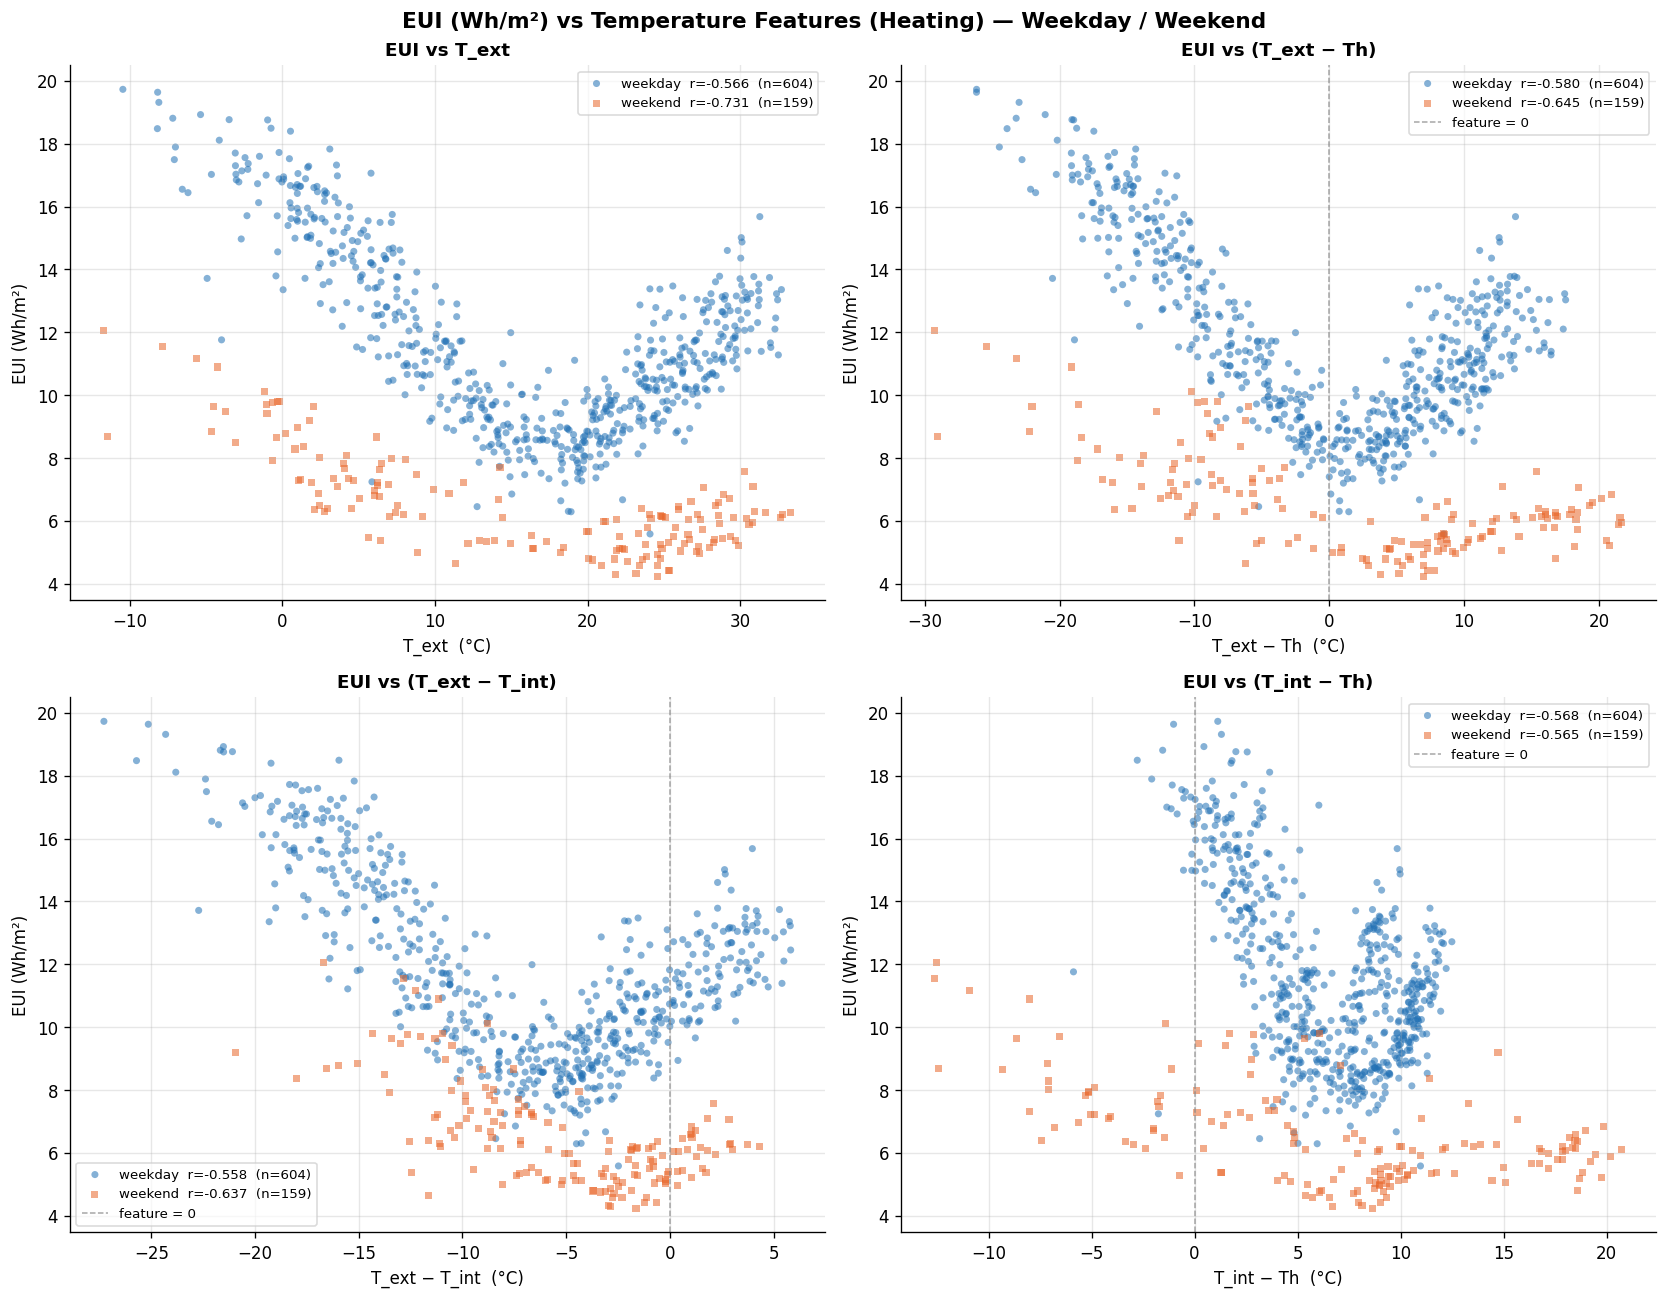

Saved: eui_vs_temp_features_heating.png

Pearson r — EUI vs each temperature feature:


,Feature,day_type,n,Pearson_r,p_value
0,T_ext (°C),weekday,604,-0.5660,1.88e-52
1,T_ext (°C),weekend,159,-0.7313,7.06e-28
2,T_ext − Th (°C),weekday,604,-0.5796,1.73e-55
3,T_ext − Th (°C),weekend,159,-0.6455,4.12e-20
4,T_ext − T_int (°C),weekday,604,-0.5576,1.19e-50
5,T_ext − T_int (°C),weekend,159,-0.6366,1.92e-19
6,T_int − Th (°C),weekday,604,-0.5683,5.78e-53
7,T_int − Th (°C),weekend,159,-0.5648,8.91e-15


In [37]:
from scipy.stats import pearsonr

# ── Merge per-year Th into df to compute derived temperature features ────
cp_merge = cp[['year', 'day_type', 'Th']].copy()
cp_merge['year'] = cp_merge['year'].astype(int)

df_feat = df.merge(cp_merge, on=['year', 'day_type'], how='left')

# ── Derived features for Heating ──────────────────────────────────────────────────
df_feat['T_ext_minus_Th']   = df_feat['temp_external'] - df_feat['Th']
df_feat['T_ext_minus_Tint'] = df_feat['temp_external'] - df_feat['temp_internal']
df_feat['T_int_minus_Th']    = df_feat['temp_internal'] - df_feat['Th']

# ── Plot ───────────────────────────────────────────────────────────────────────
features = [
    ('temp_external',    'T_ext  (°C)',         'EUI vs T_ext'),
    ('T_ext_minus_Th',   'T_ext − Th  (°C)',    'EUI vs (T_ext − Th)'),
    ('T_ext_minus_Tint', 'T_ext − T_int  (°C)', 'EUI vs (T_ext − T_int)'),
    ('T_int_minus_Th',    'T_int − Th  (°C)',    'EUI vs (T_int − Th)'),
]

WD_COL = '#2271B5'
WE_COL = '#E9672A'

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('EUI (Wh/m²) vs Temperature Features (Heating) — Weekday / Weekend',
             fontsize=13, fontweight='bold')

for ax, (col, xlabel, title) in zip(axes.flatten(), features):
    for dt, color, marker in [('weekday', WD_COL, 'o'), ('weekend', WE_COL, 's')]:
        sub = df_feat[df_feat['day_type'] == dt].dropna(subset=[col, 'EUI_Wh_m2'])
        r, _ = pearsonr(sub[col], sub['EUI_Wh_m2'])
        ax.scatter(sub[col], sub['EUI_Wh_m2'],
                   color=color, marker=marker, s=18, alpha=0.55,
                   edgecolors='none',
                   label=f'{dt}  r={r:+.3f}  (n={len(sub)})')

    # vertical reference at 0 for derived features
    if col != 'temp_external':
        ax.axvline(0, color='gray', lw=0.9, ls='--', alpha=0.7,
                   label='feature = 0')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('EUI (Wh/m²)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.savefig('eui_vs_temp_features_heating.png', bbox_inches='tight')
plt.show()
print('Saved: eui_vs_temp_features_heating.png')

# ── Pearson r summary table ───────────────────────────────────────────────────
print('\nPearson r — EUI vs each temperature feature:')
rows_r = []
for col, xlabel, _ in features:
    for dt in ['weekday', 'weekend']:
        sub = df_feat[df_feat['day_type'] == dt].dropna(subset=[col, 'EUI_Wh_m2'])
        r, pval = pearsonr(sub[col], sub['EUI_Wh_m2'])
        rows_r.append({'Feature': xlabel, 'day_type': dt,
                        'n': len(sub), 'Pearson_r': round(r, 4),
                        'p_value': f'{pval:.2e}'})
display(pd.DataFrame(rows_r))

## 2 · Helper functions

In [30]:
def rplus(x):
    """Positive part operator: max(0, x)."""
    return np.maximum(x, 0)


def get_cp(year_key, day_type):
    """Return (Tc, Th, Eb_kWh) for a given year / day_type from cp_params."""
    if year_key == 'all':
        rows = cp[cp['day_type'] == day_type]
        if rows.empty:
            raise ValueError(f"No cp_params for day_type='{day_type}'")
        if 'n_samples' in rows.columns:
            w  = rows['n_samples'].values.astype(float)
            Tc = float(np.average(rows['Tc'].values,    weights=w))
            Th = float(np.average(rows['Th'].values,    weights=w))
            Eb = float(np.average(rows['alpha'].values, weights=w)) * floor_area_m2 / 1000
        else:
            Tc = float(rows['Tc'].mean())
            Th = float(rows['Th'].mean())
            Eb = float(rows['alpha'].mean()) * floor_area_m2 / 1000
        return Tc, Th, Eb
    row = cp[(cp['year'] == str(year_key)) & (cp['day_type'] == day_type)]
    if row.empty:
        raise ValueError(f"No cp_params for year='{year_key}', day_type='{day_type}'")
    return (float(row['Tc'].values[0]),
            float(row['Th'].values[0]),
            float(row['alpha'].values[0]) * floor_area_m2 / 1000)


def get_subset(df_full, year_key, day_type):
    """Filter dataframe by year and day_type."""
    sub = df_full.copy()
    if year_key != 'all':
        sub = sub[sub['year'] == int(year_key)]
    return sub[sub['day_type'] == day_type].reset_index(drop=True)


def compute_metrics(Eh_actual, Eh_pred, n_params):
    """Compute goodness-of-fit metrics for a heating model."""
    n      = len(Eh_actual)
    r2     = r2_score(Eh_actual, Eh_pred)
    rmse   = np.sqrt(mean_squared_error(Eh_actual, Eh_pred))
    ssr    = np.sum((Eh_actual - Eh_pred) ** 2)
    cvrmse = rmse / (np.mean(Eh_actual) + 1e-12) * 100
    nmbe   = np.mean(Eh_pred - Eh_actual) / (np.mean(Eh_actual) + 1e-12) * 100
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - n_params - 1, 1)
    aic    = n * np.log(ssr / n + 1e-12) + 2 * n_params
    bic    = n * np.log(ssr / n + 1e-12) + n_params * np.log(n)
    return dict(R2=r2, Adj_R2=adj_r2, RMSE=rmse,
                CV_RMSE_pct=cvrmse, NMBE_pct=nmbe,
                AIC=aic, BIC=bic, n_params=n_params)


print('Helper functions defined.')

Helper functions defined.


## 3 · Heating feature variables

The two candidate variables for the heating model are:

| # | Label | Expression | Role in heating equation |
|---|---|---|---|
| X1 | Th-Text | $(T_h - T_{ext})^+$ | Primary heating driver |
| X2 | Tint-Th | $(T_{int} - T_h)^+$ | Indoor temperature influence relative to heating setpoint |

In [31]:
# ── Feature registry ─────────────────────────────────────────────────────────
FEATURE_LABELS = ['Th-Text', 'Tint-Th']
N_FEATURES     = len(FEATURE_LABELS)

def build_feature_matrix(T_ext, T_int, Tc, Th):
    """Build (2 x n) feature matrix for a heating-period subset."""
    return np.array([
        rplus(Th - T_ext),      # X1  (Th-Text)+
        rplus(T_int - Th),      # X2  (Tint-Th)+
    ])

# ── Define the single model combination ──────────────────────────────────
ALL_COMBOS = [(0, 1)] # Use both features

print(f'Using model with variables: {", ".join(FEATURE_LABELS)}')

Using model with variables: Th-Text, Tint-Th


## 4 · Heating-period filter

Only rows that satisfy **both** conditions are used for fitting:

| Condition | Meaning |
|---|---|
| $T_{ext} < T_h$ | Exterior temperature is below the heating setpoint |
| $E > E_b$ | Measured electricity exceeds the base load (active heating) |

The fitting target is the **heating energy above base load**:
$$E_h = \max(E - E_b,\ 0)$$

In [32]:
def get_heating_subset(df_full, year_key, day_type):
    """
    Return heating-active rows and change-point parameters.

    For a specific year: filters days where T_ext < Th_year AND kWh > Eb_year.
    For year_key='all' : pools heating days from EACH individual year using
                         that year's own Th/Eb.
                         Tc/Th/Eb returned are the weighted-average values.

    Returns: (sub_heat, Tc, Th, Eb)
    """
    Tc, Th, Eb = get_cp(year_key, day_type)   # weighted avg for 'all'

    if year_key != 'all':
        sub  = get_subset(df_full, year_key, day_type)
        mask = (sub['temp_external'] < Th) & (sub['electricity_kWh'] > Eb)
        return sub[mask].reset_index(drop=True), Tc, Th, Eb

    # ── year_key == 'all': pool per-year heating selections ──────────────────
    year_rows = cp[(cp['day_type'] == day_type) & (cp['year'] != 'all')]
    frames = []
    for _, row in year_rows.iterrows():
        yr_i  = int(row['year'])
        Th_i  = float(row['Th'])
        Eb_i  = float(row['alpha']) * floor_area_m2 / 1000
        sub_i = get_subset(df_full, yr_i, day_type)
        mask_i = (sub_i['temp_external'] < Th_i) & (sub_i['electricity_kWh'] > Eb_i)
        frames.append(sub_i[mask_i])
    if not frames:
        return pd.DataFrame(), Tc, Th, Eb
    return pd.concat(frames, ignore_index=True), Tc, Th, Eb


print('Heating-period filter defined.')
print()
# Quick preview: how many heating days per day_type?
for dt in ['weekday', 'weekend']:
    try:
        s, _, Th, Eb = get_heating_subset(df, 'all', dt)
        print(f'  {dt}: {len(s)} heating days  (Th={Th:.1f}°C, Eb={Eb:.2f} kWh)')
    except Exception as e:
        print(f'  {dt}: {e}')

Heating-period filter defined.

  weekday: 282 heating days  (Th=16.5°C, Eb=45.18 kWh)
  weekend: 70 heating days  (Th=14.2°C, Eb=28.37 kWh)


## 5 · Fit heating model

The model is an additive combination of the 2 features:

$$\hat{E}_h = c_1 \cdot (T_h - T_{ext})^+ + c_2 \cdot (T_{int} - T_h)^+$$

`curve_fit` settings:
- `bounds = (0, np.inf)` — all coefficients $c_j \geq 0$ (physically required)
- `method = 'trf'` — Trust Region Reflective, handles bound constraints
- `maxfev = 20000` — generous iteration budget

Change `YEAR_KEY` to an integer (e.g. `2021`) to run on a single year.

In [33]:
YEAR_KEYS = ['all', 2021, 2022, 2023, 2024]

all_heating_results = {}   # { year_key : { day_type : result dict } }

for YEAR_KEY in YEAR_KEYS:
    all_heating_results[YEAR_KEY] = {}

    print(f'\n{"#"*70}')
    print(f'  YEAR KEY: {YEAR_KEY}')
    print(f'{"#"*70}')

    for day_type in ['weekday', 'weekend']:

        try:
            sub_heat, Tc, Th, Eb = get_heating_subset(df, YEAR_KEY, day_type)
        except Exception as e:
            print(f'  {day_type}: skipped — {e}')
            continue

        if len(sub_heat) < 10:
            print(f'  {day_type}: skipped — only {len(sub_heat)} heating rows')
            continue

        T_ext     = sub_heat['temp_external'].values
        T_int     = sub_heat['temp_internal'].values
        Eh_actual = np.maximum(sub_heat['electricity_kWh'].values - Eb, 0)
        n_total   = len(Eh_actual)

        Xall = build_feature_matrix(T_ext, T_int, Tc, Th)

        print(f'\n{"="*68}')
        print(f'  {day_type.upper()}  |  n_heating={n_total}  '
              f'Th={Th:.2f}°C  Eb={Eb:.2f} kWh')
        print(f'{"="*68}')
        print(f'  {"Variable combination":<38} {"R²":>7}  {"AIC":>9}  Coefficients')
        print(f'  {"-"*95}')

        # Only one model to fit
        combo = ALL_COMBOS[0]
        k         = len(combo)
        var_names = [FEATURE_LABELS[j] for j in combo]
        X_sub     = Xall[list(combo), :]

        def make_additive_model(X_fixed):
            def model(_, *coeffs):
                return sum(c * X_fixed[i] for i, c in enumerate(coeffs))
            return model

        model_fn = make_additive_model(X_sub)

        try:
            popt, pcov = curve_fit(
                model_fn,
                np.zeros(n_total),
                Eh_actual,
                p0     = [1.0] * k,
                bounds = (0, np.inf),
                method = 'trf',
                maxfev = 20000,
            )
            perr    = np.sqrt(np.diag(pcov))
            Eh_pred = model_fn(None, *popt)
            mets    = compute_metrics(Eh_actual, Eh_pred, k)
            status  = 'OK'
        except Exception as e:
            popt    = [np.nan] * k
            perr    = [np.nan] * k
            Eh_pred = np.full(n_total, np.nan)
            mets    = {m: np.nan for m in
                       ['R2','Adj_R2','RMSE','CV_RMSE_pct','NMBE_pct','AIC','BIC','n_params']}
            status  = f'FAILED: {e}'

        rec = {
            'n_vars'   : k,
            'variables': ', '.join(var_names),
            'combo_idx': combo,
            'coeffs'   : {var_names[i]: round(float(popt[i]), 6) for i in range(k)},
            'perr'     : {var_names[i]: round(float(perr[i]), 6) for i in range(k)},
            'Th'       : Th,
            'Eb'       : Eb,
            'n'        : n_total,
            'status'   : status,
            'Eh_pred'  : Eh_pred,
            'Eh_actual': Eh_actual,
            **mets,
        }

        if status == 'OK':
            coeff_str = '  '.join(f'{v}={popt[i]:.3f}' for i, v in enumerate(var_names))
            print(f'  {", ".join(var_names):<38} '
                  f'{mets["R2"]:>7.4f}  {mets["AIC"]:>9.2f}  {coeff_str}')
        else:
            print(f'  {", ".join(var_names):<38} *** {status}')

        all_heating_results[YEAR_KEY][day_type] = rec
        print(f'\n  Completed: {day_type} model fitted.')

# backward compatibility
heating_results = all_heating_results.get('all', {})
YEAR_KEY = 'all'


######################################################################
  YEAR KEY: all
######################################################################

  WEEKDAY  |  n_heating=282  Th=16.46°C  Eb=45.18 kWh
  Variable combination                        R²        AIC  Coefficients
  -----------------------------------------------------------------------------------------------
  Th-Text, Tint-Th                        0.8000    1103.83  Th-Text=2.494  Tint-Th=0.131

  Completed: weekday model fitted.

  WEEKEND  |  n_heating=70  Th=14.21°C  Eb=28.37 kWh
  Variable combination                        R²        AIC  Coefficients
  -----------------------------------------------------------------------------------------------
  Th-Text, Tint-Th                        0.6161     233.57  Th-Text=1.214  Tint-Th=0.444

  Completed: weekend model fitted.

######################################################################
  YEAR KEY: 2021
###############################################

## 6 · Summary table — heating model results

In [34]:
def build_summary_df(results_dict):
    rows = []
    for year_key, year_res in results_dict.items():
        for day_type, r in year_res.items():
            if not r: continue
            row = {
                'Year'     : year_key,
                'Day Type' : day_type,
                'n_vars'   : r['n_vars'],
                'Variables': r['variables'],
                'n'        : r['n'],
                'Status'   : r['status'],
            }
            for label in FEATURE_LABELS:
                row[label] = r['coeffs'].get(label, np.nan)
            for m in ['R2', 'Adj_R2', 'RMSE', 'CV_RMSE_pct', 'NMBE_pct', 'AIC', 'BIC']:
                row[m] = r.get(m, np.nan)
            row['ASHRAE_pass'] = (
                r.get('CV_RMSE_pct', 999) <= 25 and abs(r.get('NMBE_pct', 999)) <= 5
            ) if r['status'] == 'OK' else False
            rows.append(row)
    return pd.DataFrame(rows)

summary_df = build_summary_df(all_heating_results)

# Display ranked table for every year_key
for year_key in YEAR_KEYS:
    sdf = summary_df[summary_df['Year'] == year_key]
    if sdf.empty: continue

    print(f'\n{"="*70}')
    print(f'  YEAR={year_key} — Heating Model Results')
    print(f'{"="*70}')
    display(sdf[['Day Type','n_vars','Variables',
                 'R2','Adj_R2','RMSE','CV_RMSE_pct','NMBE_pct',
                 'AIC','BIC','ASHRAE_pass']].round(4))


  YEAR=all — Heating Model Results


,Day Type,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
0,weekday,2,"Th-Text, Tint-Th",0.8000,0.7985,7.0291,27.0251,-0.655,1103.8291,1111.1130,False
1,weekend,2,"Th-Text, Tint-Th",0.6161,0.6047,5.1541,38.8405,0.837,233.5709,238.0679,False



  YEAR=2021 — Heating Model Results


,Day Type,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
2,weekday,2,"Th-Text, Tint-Th",0.8563,0.8515,5.6803,23.7408,-0.3719,222.8619,227.1481,True
3,weekend,2,"Th-Text, Tint-Th",0.6832,0.6568,5.4834,37.2104,1.9018,95.8928,98.4844,False



  YEAR=2022 — Heating Model Results


,Day Type,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
4,weekday,2,"Th-Text, Tint-Th",0.8606,0.8555,5.5113,23.1078,-0.5754,198.5756,202.6617,True
5,weekend,2,"Th-Text, Tint-Th",0.5380,0.4225,5.2465,37.9969,2.6430,40.4662,41.2620,False



  YEAR=2023 — Heating Model Results


,Day Type,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
6,weekday,2,"Th-Text, Tint-Th",0.7756,0.7654,6.7147,29.7391,-0.4298,183.0045,186.7048,False



  YEAR=2024 — Heating Model Results


,Day Type,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
7,weekday,2,"Th-Text, Tint-Th",0.8236,0.8179,6.3829,20.7034,-0.1612,244.9707,249.3195,True
8,weekend,2,"Th-Text, Tint-Th",0.6858,0.6160,4.0287,27.0691,0.2089,37.4429,38.4127,False


## 7 · Model results — actual vs predicted (time series & scatter)

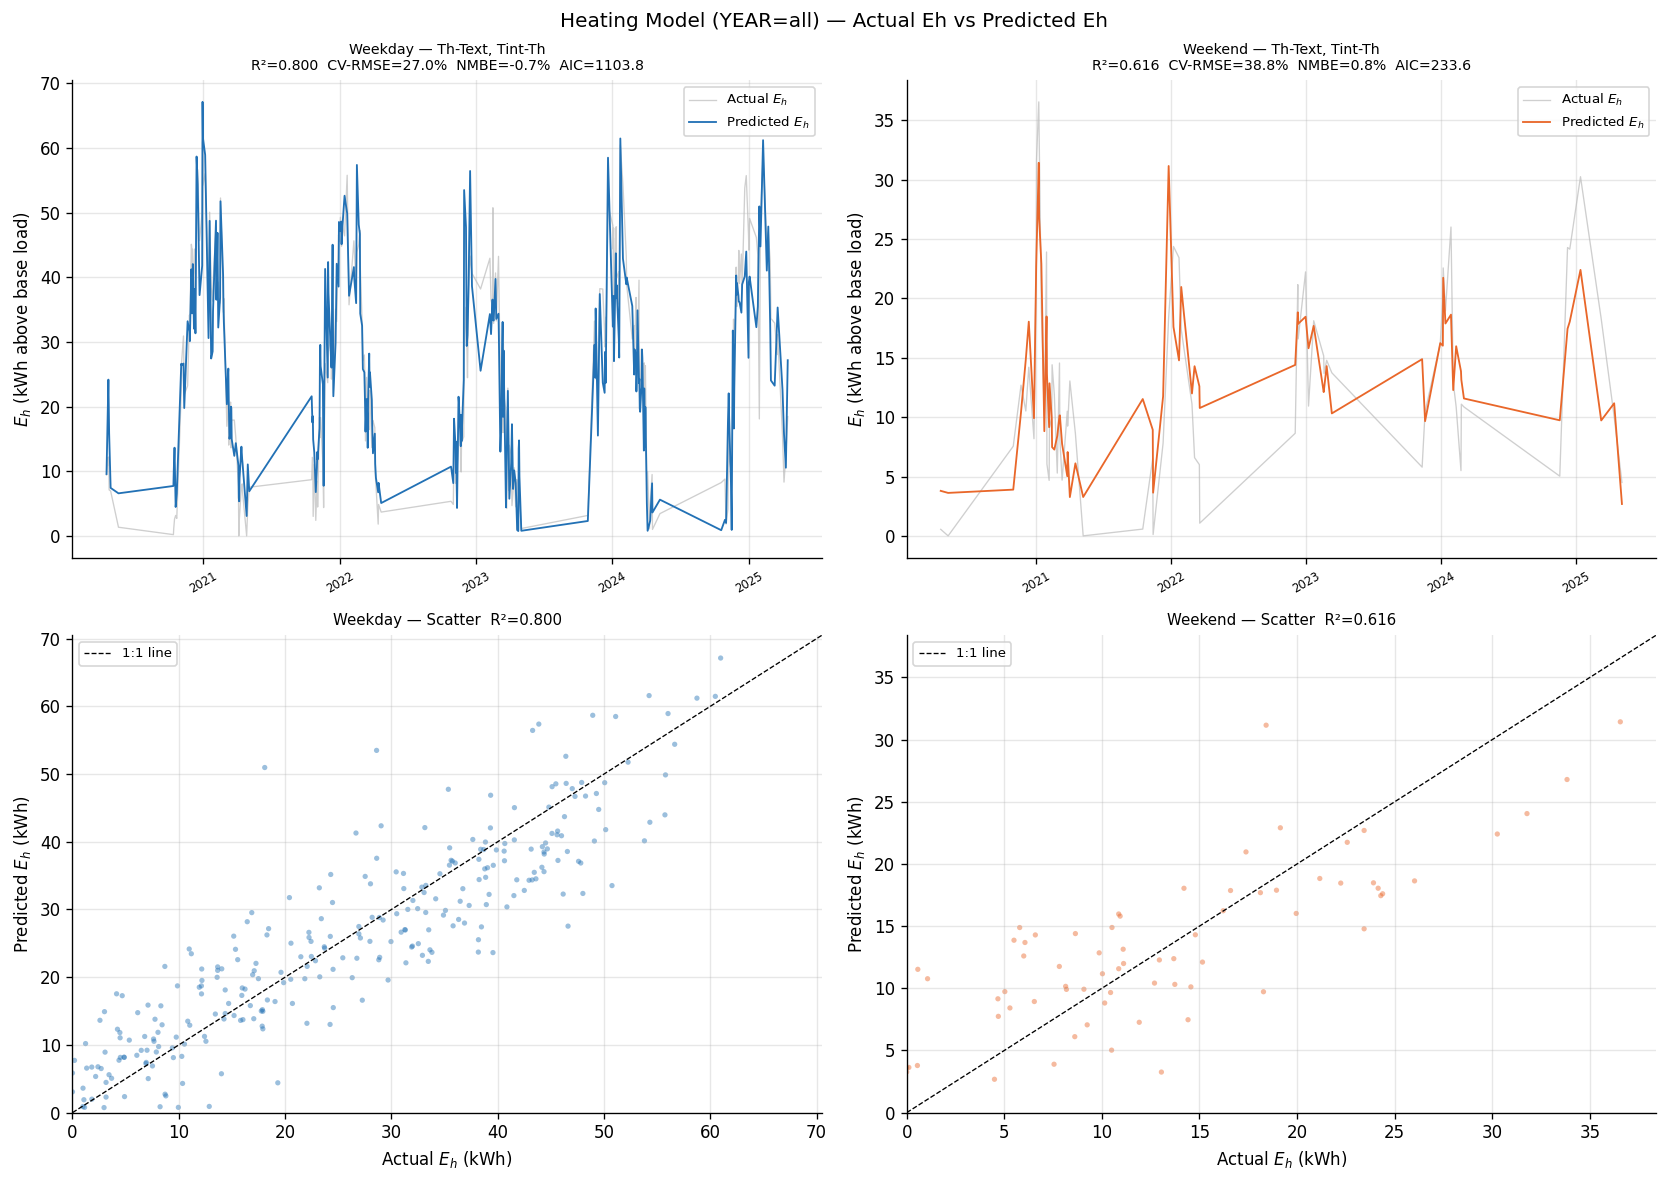

Saved: heating_model_actual_vs_pred.png


In [35]:
# Plot for YEAR_KEY = 'all'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Heating Model (YEAR={YEAR_KEY}) — Actual Eh vs Predicted Eh', fontsize=12)

results_to_plot = all_heating_results.get(YEAR_KEY, {})

for col_idx, day_type in enumerate(['weekday', 'weekend']):
    if day_type not in results_to_plot or not results_to_plot[day_type]:
        for row_i in range(2):
            axes[row_i, col_idx].set_visible(False)
        continue

    bm_rec = results_to_plot[day_type]

    Eh_actual = bm_rec['Eh_actual']
    Eh_pred   = bm_rec['Eh_pred']
    col       = COLORS[day_type]

    sub_heat, _, _, _ = get_heating_subset(df, YEAR_KEY, day_type)
    dates = sub_heat['datetime'].values

    # ── Time series ──────────────────────────────────────────────────────────
    ax_ts = axes[0, col_idx]
    ax_ts.plot(dates, Eh_actual,
               color=COLORS[f'actual_{day_type[:2]}'], lw=0.8, alpha=0.7,
               label='Actual $E_h$')
    ax_ts.plot(dates, Eh_pred, color=col, lw=1.1,
               label='Predicted $E_h$')
    ax_ts.set_title(
        f'{day_type.capitalize()} — {bm_rec["variables"]}\n'
        f'R²={bm_rec["R2"]:.3f}  CV-RMSE={bm_rec["CV_RMSE_pct"]:.1f}%  '
        f'NMBE={bm_rec["NMBE_pct"]:.1f}%  AIC={bm_rec["AIC"]:.1f}',
        fontsize=8.5
    )
    ax_ts.set_ylabel('$E_h$ (kWh above base load)')
    ax_ts.legend(fontsize=8)
    ax_ts.tick_params(axis='x', rotation=30, labelsize=7)

    # ── Scatter ──────────────────────────────────────────────────────────────
    ax_sc = axes[1, col_idx]
    ax_sc.scatter(Eh_actual, Eh_pred, s=10, alpha=0.45, color=col, edgecolors='none')
    lo = min(Eh_actual.min(), Eh_pred.min()) * 0.95
    hi = max(Eh_actual.max(), Eh_pred.max()) * 1.05
    ax_sc.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 line')
    ax_sc.set_xlim(lo, hi); ax_sc.set_ylim(lo, hi)
    ax_sc.set_xlabel('Actual $E_h$ (kWh)')
    ax_sc.set_ylabel('Predicted $E_h$ (kWh)')
    ax_sc.set_title(f'{day_type.capitalize()} — Scatter  R²={bm_rec["R2"]:.3f}', fontsize=9)
    ax_sc.legend(fontsize=8)

plt.tight_layout()
plt.savefig('heating_model_actual_vs_pred.png', bbox_inches='tight')
plt.show()
print('Saved: heating_model_actual_vs_pred.png')

## 8 · Export results

In [36]:
# ═══════════════════════════════════════════════════════════════════════════
# CSV 1 — All years and day types in one file
# ═══════════════════════════════════════════════════════════════════════════
if not summary_df.empty:
    csv_out = summary_df.sort_values(['Year', 'Day Type'], key=lambda x: x.astype(str)).reset_index(drop=True)
    
    # Reorder columns for clarity
    cols = ['Year', 'Day Type', 'n', 'R2', 'Adj_R2', 'RMSE', 'CV_RMSE_pct', 'NMBE_pct', 
            'AIC', 'BIC', 'ASHRAE_pass', 'Status', 'Variables']
    
    # Add coefficient columns
    coeff_cols = [c for c in summary_df.columns if c in FEATURE_LABELS]
    cols.extend(coeff_cols)
    
    csv_out = csv_out[[c for c in cols if c in csv_out.columns]]
    
    csv_out.to_csv('heating_model_results.csv', index=False)
    print(f'Saved: heating_model_results.csv')
    print(f'  years    : {sorted([str(y) for y in csv_out["Year"].unique()])}')
    print(f'  day_types: {sorted(csv_out["Day Type"].unique())}')
    print(f'  rows     : {len(csv_out)}')
    print()
    display(csv_out.round(4))

# ═══════════════════════════════════════════════════════════════════════════
# Final console summary
# ═══════════════════════════════════════════════════════════════════════════
if not summary_df.empty:
    print('\nHeating model results summary:')
    display(
        summary_df[['Year','Day Type','n_vars','Variables',
                    'R2','CV_RMSE_pct','NMBE_pct','ASHRAE_pass']]
        .sort_values(['Year','Day Type'], key=lambda x: x.astype(str))
        .round(4)
    )

Saved: heating_model_results.csv
  years    : ['2021', '2022', '2023', '2024', 'all']
  day_types: ['weekday', 'weekend']
  rows     : 9



,Year,Day Type,n,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass,Status,Variables,Th-Text,Tint-Th
0,2021,weekday,63,0.8563,0.8515,5.6803,23.7408,-0.3719,222.8619,227.1481,True,OK,"Th-Text, Tint-Th",2.5465,0.0000
1,2021,weekend,27,0.6832,0.6568,5.4834,37.2104,1.9018,95.8928,98.4844,False,OK,"Th-Text, Tint-Th",1.0995,1.2770
2,2022,weekday,57,0.8606,0.8555,5.5113,23.1078,-0.5754,198.5756,202.6617,True,OK,"Th-Text, Tint-Th",2.3452,0.2772
3,2022,weekend,11,0.5380,0.4225,5.2465,37.9969,2.6430,40.4662,41.2620,False,OK,"Th-Text, Tint-Th",1.9932,0.2962
4,2023,weekday,47,0.7756,0.7654,6.7147,29.7391,-0.4298,183.0045,186.7048,False,OK,"Th-Text, Tint-Th",2.4329,0.0000
5,2024,weekday,65,0.8236,0.8179,6.3829,20.7034,-0.1612,244.9707,249.3195,True,OK,"Th-Text, Tint-Th",2.5856,0.3286
6,2024,weekend,12,0.6858,0.6160,4.0287,27.0691,0.2089,37.4429,38.4127,False,OK,"Th-Text, Tint-Th",1.9851,0.0282
7,all,weekday,282,0.8000,0.7985,7.0291,27.0251,-0.6550,1103.8291,1111.1130,False,OK,"Th-Text, Tint-Th",2.4937,0.1306
8,all,weekend,70,0.6161,0.6047,5.1541,38.8405,0.8370,233.5709,238.0679,False,OK,"Th-Text, Tint-Th",1.2141,0.4439



Heating model results summary:


,Year,Day Type,n_vars,Variables,R2,CV_RMSE_pct,NMBE_pct,ASHRAE_pass
2,2021,weekday,2,"Th-Text, Tint-Th",0.8563,23.7408,-0.3719,True
3,2021,weekend,2,"Th-Text, Tint-Th",0.6832,37.2104,1.9018,False
4,2022,weekday,2,"Th-Text, Tint-Th",0.8606,23.1078,-0.5754,True
5,2022,weekend,2,"Th-Text, Tint-Th",0.5380,37.9969,2.6430,False
6,2023,weekday,2,"Th-Text, Tint-Th",0.7756,29.7391,-0.4298,False
7,2024,weekday,2,"Th-Text, Tint-Th",0.8236,20.7034,-0.1612,True
8,2024,weekend,2,"Th-Text, Tint-Th",0.6858,27.0691,0.2089,False
0,all,weekday,2,"Th-Text, Tint-Th",0.8000,27.0251,-0.6550,False
1,all,weekend,2,"Th-Text, Tint-Th",0.6161,38.8405,0.8370,False
